<a href="https://colab.research.google.com/github/Yaaxek/Relaciones-con-regresion-lineal/blob/main/precios_de_inmuebles_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Precificación inmobiliaria**

**Objetivo**: Estimar los precios de los inmuebles.
 * Identificar los aspectos que tienen más influencia en la precificación de los inmuebles.
 * Entender cuál de todos estos aspectos es el más relevante.
 * Precificar un inmueble nuevo.

Base de datos simplificada e inspirada en [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)



![](https://i.imgur.com/A8X79yq.jpeg)


# 1. Ajustando una recta

## Conociendo los datos

In [564]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [565]:
#Leyendo los datos
import pandas as pd
datos = pd.read_csv('/content/drive/MyDrive/Regresion Lineal/precios_casas.csv')
datos.head(2)

,Id,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0


In [566]:
#Cuáles factores fueron colectados
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           1438 non-null   int64  
 1   area_primer_piso             1438 non-null   float64
 2   tiene_segundo_piso           1438 non-null   int64  
 3   area_segundo_piso            1438 non-null   float64
 4   cantidad_banos               1438 non-null   int64  
 5   capacidad_carros_garage      1438 non-null   int64  
 6   calidad_de_cocina_excelente  1438 non-null   int64  
 7   precio_de_venta              1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [567]:
datos=datos.drop(columns='Id')
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

## Correlación

**¿Cuáles factores están relacionados con el precio de la casa? ¿Cómo es esa relación?**

El coeficiente de correlación de Pearson nos permite medir la relación lineal entre variables, ofreciendo una escala que varía de -1 a 1, la cual interpretamos según su intensidad y dirección:

* **-1**: correlación negativa perfecta: a medida que una variable aumenta, la otra disminuye.  
* **0**: no hay relación lineal entre las variables.  
* **1**: correlación positiva perfecta: a medida que una variable aumenta, la otra también aumenta.  



In [568]:
# Correlación
corr=datos.corr()

In [569]:
corr['precio_de_venta']

,precio_de_venta
area_primer_piso,0.616557
tiene_segundo_piso,0.138541
area_segundo_piso,0.305311
cantidad_banos,0.563132
capacidad_carros_garage,0.640214
calidad_de_cocina_excelente,0.496223
precio_de_venta,1.000000


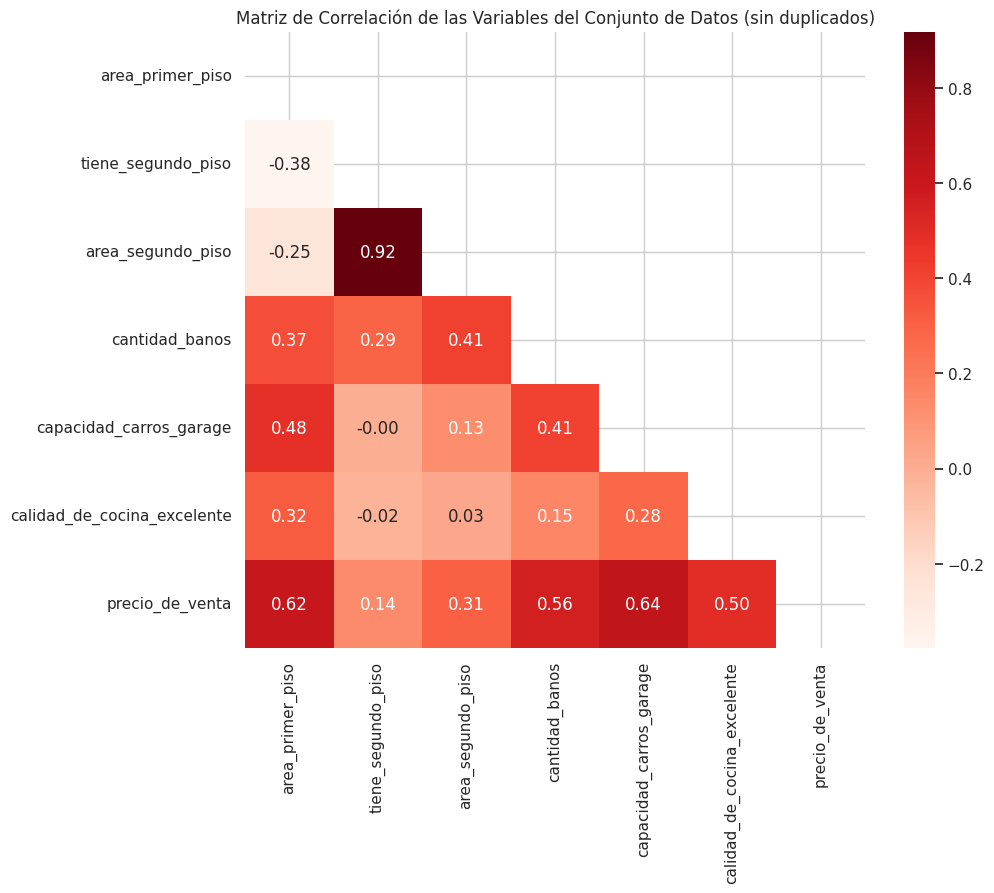

In [570]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mascara = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Reds', fmt=".2f", mask=mascara)
plt.title('Matriz de Correlación de las Variables del Conjunto de Datos (sin duplicados)')
plt.show()

## Relacionando variables

In [571]:
# importando los paquetes para la visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

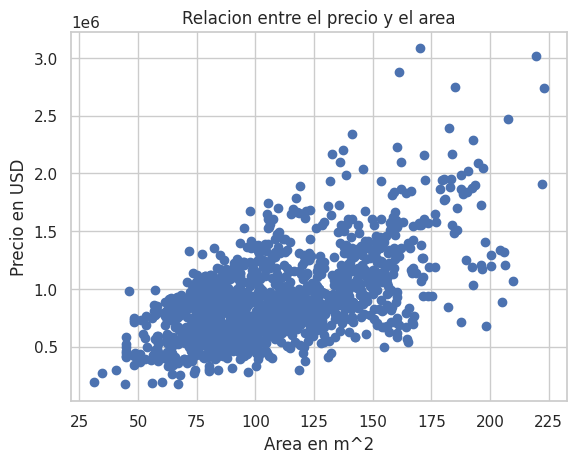

In [572]:
# Cómo se relacionan el área construída y el precio del inmueble?
plt.scatter(datos['area_primer_piso'],datos['precio_de_venta'])
plt.title('Relacion entre el precio y el area')
plt.xlabel('Area en m^2')
plt.ylabel('Precio en USD')
plt.show()

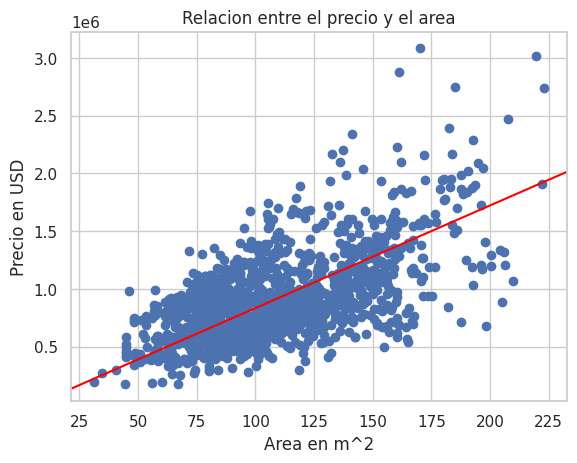

In [573]:
# Aparentemente mientras mayor es el área del primer piso, mayor es el precio de la casa.
# E si quisieramos trazar una línea que nos permita describir este comportamiento?
plt.scatter(datos['area_primer_piso'],datos['precio_de_venta'])
plt.axline(xy1=(40,300000),xy2=(175,1500000),color='red')
plt.title('Relacion entre el precio y el area')
plt.xlabel('Area en m^2')
plt.ylabel('Precio en USD')
plt.show()

## Mejor recta

In [574]:
# Cuál es la recta que mejor se ajusta a esta relación
px.scatter(datos,x='area_primer_piso',y='precio_de_venta',trendline_color_override='red',trendline='ols')

# 2. Explicando la recta
Ajustamos una recta entre los $m^2$ del primer piso y el precio de la casa. Queremos explicar el precio de la casa a partir de su tamaño, por eso decimos que:

* Variable explicativa/independiente: Área del primer piso  
* Variable de respuesta/dependiente: Precio de la casa  

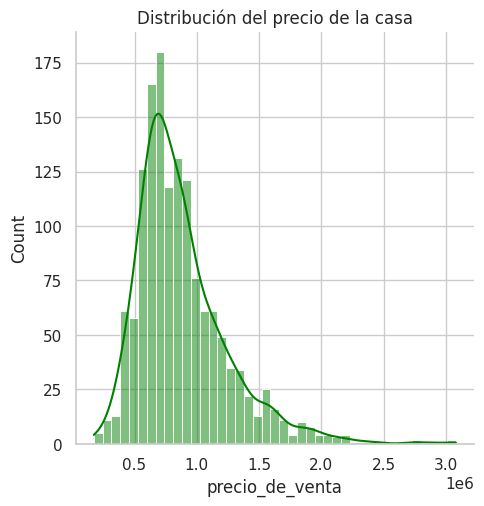

In [575]:
#Quién es nuestra variable de respuesta?
sns.displot(datos['precio_de_venta'],kde=True,color='green')
plt.title('Distribución del precio de la casa')
plt.show()

### Separando datos para entrenamiento y para prueba

El conjunto de **entrenamiento** se utiliza para ajustar el modelo, mientras que el conjunto de **prueba** se usa para evaluar su desempeño al predecir precios de viviendas no vistos durante el entrenamiento, lo que ayuda a la generalización del modelo.

In [576]:
# import train_test_split
from sklearn.model_selection import train_test_split
y=datos['precio_de_venta']
X=datos.drop(columns='precio_de_venta')
#Random_state garantizar la reproducibilidad
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=230)


In [577]:
#Datos de entrenamiento para usar la fórmula
df_train=pd.DataFrame(X_train)
df_train['precio_de_venta']=y_train

In [578]:
# import ols
from statsmodels.formula.api import ols

In [579]:
# ajustando el primer modelo
model_0=ols('precio_de_venta ~ area_primer_piso', data=df_train).fit()

## Analizando los coeficientes

(intensidad, dirección y significancia)




In [580]:
# visualizando los parámetros
model_0.params

,0
Intercept,152909.288334
area_primer_piso,6793.641641


In [581]:
# El resumen del modelo
print(model_0.summary())

                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          2.22e-105
Time:                        04:47:39   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.529e+05   3.07e+04  

- El **punto de intercepción** es el valor esperado del precio de la casa cuando todas las demás variables son cero. En este caso, cuando todas las demás variables, incluida el área del primer piso, son cero, el precio esperado de la casa es de $145.196,40. No siempre se tiene una interpretación práctica para este número.

- El **efecto individual** del área es de \$6.833,97. Esto indica que por cada metro cuadrado adicional al área del primer piso, se espera que el precio de la casa aumente en promedio \$6.833,97.

<img src="https://i.ibb.co/CJwfMgW/coeficientes.png" alt="coeficientes" border="0">


## Explicabilidad del modelo

**¿En qué medida la variación del área explica los diversos precios de las casas?**  

En este caso, recurrimos a la métrica R², el coeficiente de determinación. El R² varía de 0 a 1, donde 1 indica un ajuste perfecto del modelo a los datos, es decir, todas las variaciones en la variable dependiente son explicadas por las variables independientes en el modelo. Por otro lado, un R² de 0 indica que el modelo no explica ninguna variabilidad en la variable dependiente.

In [582]:
# observando el R²
model_0.rsquared.round(2)

np.float64(0.38)

El area del primer piso explica en un 37% la variacion del precio de la casa.

## Entendiendo el resíduo

In [583]:
# Quiénes son los residuos?
model_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


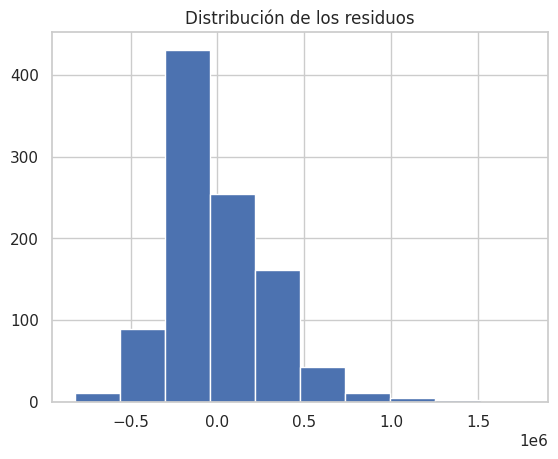

In [584]:
# Cómo están distribuidos
model_0.resid.hist()
plt.title('Distribución de los residuos')
plt.show()

<img src="https://i.ibb.co/zGTB35V/residuos.png" alt="residuos" border="0">

## Obteniendo el R² de la previsión

In [585]:
# definiendo la 'Y' prevista
y_predict=model_0.predict(X_test)

In [586]:
# importando el r2_score
from sklearn.metrics import r2_score

In [587]:
# mostrando el resultado de r²
print(f'El coeficiente de determinacion R2 para el modelo con los datos de prueba es de: {round(r2_score(y_test,y_predict),2)}')

El coeficiente de determinacion R2 para el modelo con los datos de prueba es de: 0.39


# 3. Añadiendo otras características

El modelo con un solo factor nos mostró un R² de 0.38, es decir, aproximadamente el 38% de la variación observada en los precios de las casas puede explicarse por la variación en el área.  
Esto indica que aún existe una cantidad significativa de variación que no está siendo capturada por este modelo específico. Analizaremos otros factores para explicar el precio de las casas.

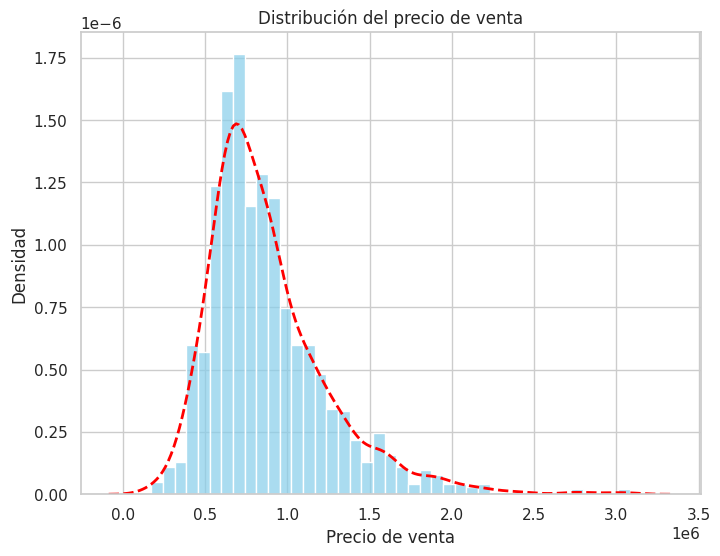

In [588]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 6))

sns.histplot(datos['precio_de_venta'],
             kde=False,
             color='skyblue',
             alpha=0.7,
             stat='density')

sns.kdeplot(datos['precio_de_venta'],
            color='red',
            linewidth=2,
            linestyle='--')

plt.title('Distribución del precio de venta')
plt.xlabel('Precio de venta')
plt.ylabel('Densidad')
plt.show()

## Analizando los factores

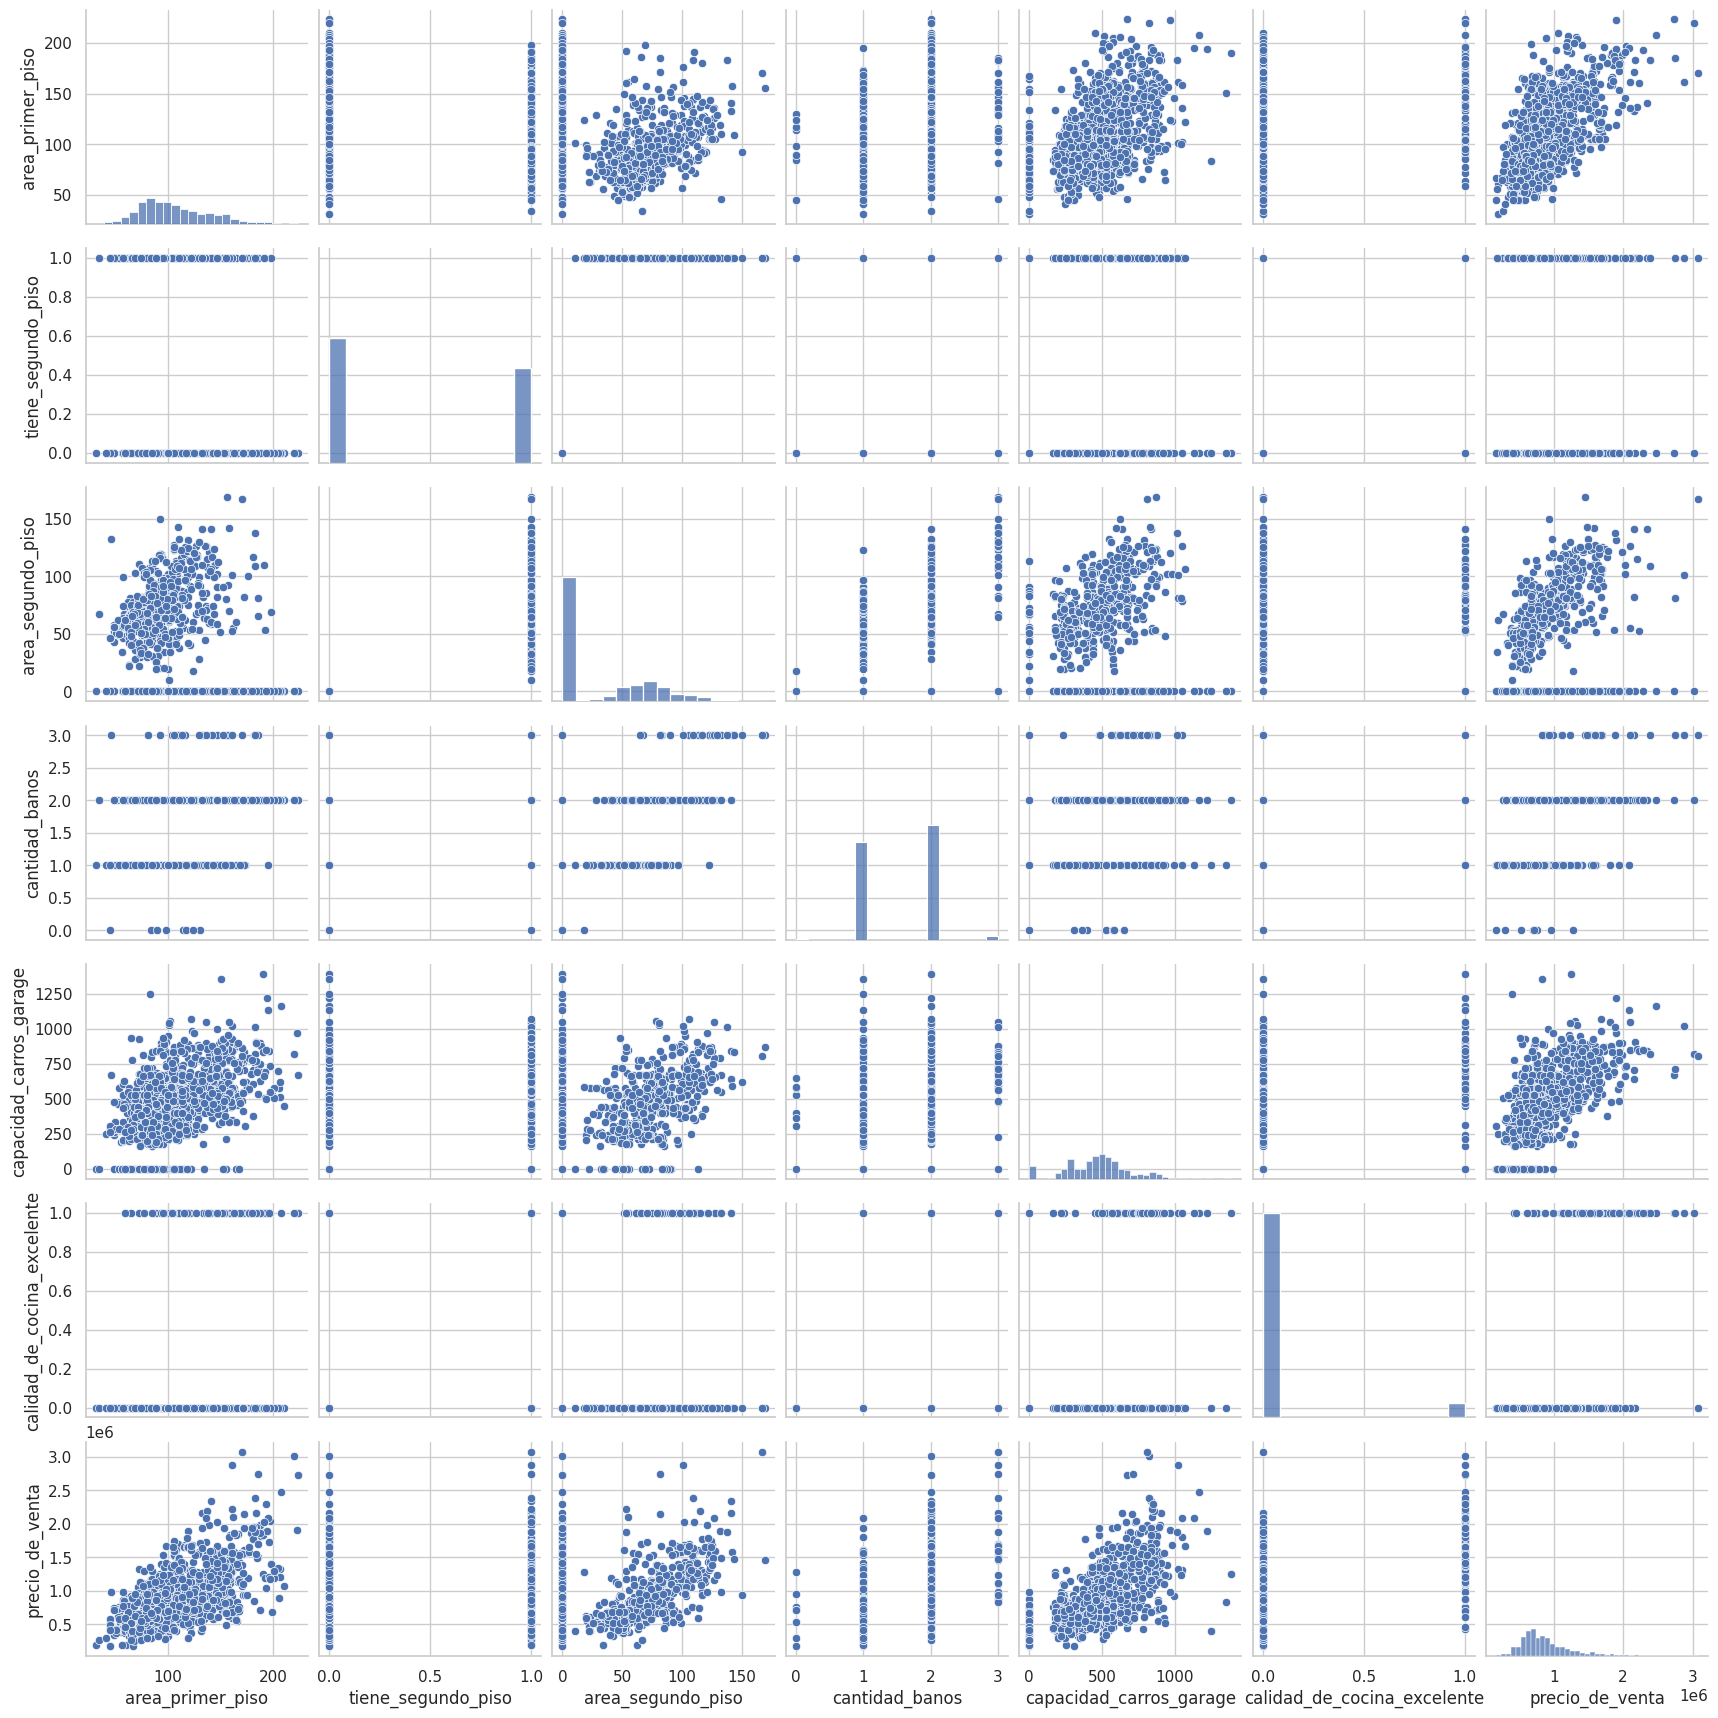

In [589]:
# cuáles otras características podrían explicar el precio de los inmuebles?
sns.pairplot(datos)

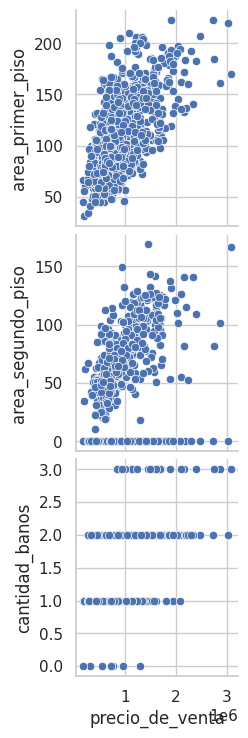

In [590]:
#Vamos a analizar solamente y_vars='precio_de_venta'
sns.pairplot(datos,y_vars=['area_primer_piso','area_segundo_piso','cantidad_banos'],x_vars='precio_de_venta')

## Añadiendo factores al modelo

In [591]:
# importando la api de statsmodels
import statsmodels.api as sm

In [592]:
# Añadiendo una constante
X_train=sm.add_constant(X_train)
X_train.head()

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [593]:
X_train.columns

Index(['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente'],
      dtype='object')

In [594]:
# Creando el modelo de regresión (con todas las variables): saturado
model_1=sm.OLS(y_train,X_train[['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']]).fit()

In [595]:
# Modelo sin el área del segundo piso
model_2=sm.OLS(y_train,X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']]).fit()

In [636]:
# Modelo sin la información del garage
# Modelo sin el área del segundo piso
model_3=sm.OLS(y_train,X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos',
       'calidad_de_cocina_excelente']]).fit()

In [597]:
# Resumen del modelos
modelos=[model_0,model_1,model_2,model_3]

for i,j in enumerate(modelos):
  print(f'********************************************************\n******** El modelo {i} tiene el siguiente resumen ********\n********************************************************')
  print(j.summary(),'\n\n')


********************************************************
******** El modelo 0 tiene el siguiente resumen ********
********************************************************
                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          2.22e-105
Time:                        04:47:50   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err 

In [598]:
for i,j in enumerate(modelos):
  print(f'El coeficiente de determinacion R^2 del modelo {i}: {j.rsquared.round(2)}')

El coeficiente de determinacion R^2 del modelo 0: 0.38
El coeficiente de determinacion R^2 del modelo 1: 0.74
El coeficiente de determinacion R^2 del modelo 2: 0.71
El coeficiente de determinacion R^2 del modelo 3: 0.65


## Comparando los modelos
Cuál es el modelo?


In [599]:
# Cuántos parámetros tiene el modelo?
model_3.params

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


# 4. Precificando las casas

## Obteniendo el R² de la previsión

In [600]:
# Añadiendo una constante en X_test
X_test=sm.add_constant(X_test)
X_test.head(2)

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
997,1.0,94.9438,0,0.0000,1,280,0
805,1.0,74.1342,1,78.2218,2,595,0


In [601]:
# Previsión con el modelo 3
prevision_3 = model_3.predict(X_test[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos',
       'calidad_de_cocina_excelente']])

In [602]:
# Cuál es el r² de la previsión?
print(f'El coeficiente R^2 de la base de prevision es: {model_3.rsquared.round(2)}')

El coeficiente R^2 de la base de prevision es: 0.65


In [603]:
# Cuál es el R² del entrenamiento?
print(f'El coeficiente R^2 de la base de entrenamiento es: {round(r2_score(y_test,prevision_3),2)}')

El coeficiente R^2 de la base de entrenamiento es: 0.64


## Precificando una casa

<img src="https://i.ibb.co/SvG4V4j/costo.png" alt="costo" border="0">

In [604]:
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

In [605]:
#Nuevo inmueble
nuevo_inmueble=pd.DataFrame({
    'const':[1],
    'area_primer_piso':[120],
    'tiene_segundo_piso':[1],
    'cantidad_banos':[2],
    'calidad_de_cocina_excelente':[0]
})

In [606]:
# Cuál es el precio del inmueble de acuerdo con el modelo 0?
model_0.predict(nuevo_inmueble['area_primer_piso']).round(2)

,0
0,968146.29


In [607]:
#Cuál es el precio del inmueble de acuerdo con el modelo 3?
model_3.predict(nuevo_inmueble).round(2)

,0
0,1123758.24


In [608]:
model_3.params

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


Recibiste una solicitud para estimar el precio de una casa con las siguientes características:



In [609]:
solicitud=pd.DataFrame({
    'const':[1],
    'area_primer_piso':[98],
    'tiene_segundo_piso':[0],
    'cantidad_banos':[1],
    'calidad_de_cocina_excelente':[1]
})

In [610]:
model_0.predict(solicitud['area_primer_piso']).round(2)

,0
0,818686.17


In [611]:
model_3.predict(solicitud).round(2)

,0
0,1063173.85


## Precificando varias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [612]:
# Leyendo varias casas?
nuevas_casas = pd.read_csv('/content/drive/MyDrive/Regresion Lineal/nuevas_casas.csv',sep=';')
nuevas_casas.head(2)

,Casa,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1,150,1,2,1
1,2,180,0,3,1


In [613]:
nuevas_casas.drop(columns='Casa',inplace=True)

In [614]:
# Añadiendo una constante
nuevas_casas=sm.add_constant(nuevas_casas)

In [615]:
# Cuál es el precio de estas nuevas casas?
# precio_casas = pd.DataFrame()
#precio_casas=pd.DataFrame()
nuevas_casas['Precio de Venta']=model_3.predict(nuevas_casas).round(2)
nuevas_casas

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente,Precio de Venta
0,1.0,150,1,2,1,1751739.07
1,1.0,180,0,3,1,1863057.99
2,1.0,120,1,2,1,1568149.47
3,1.0,200,1,3,1,2206758.02
4,1.0,160,0,2,1,1591628.64
5,1.0,140,1,2,0,1246151.31
6,1.0,170,0,3,0,1357470.23
7,1.0,190,1,2,0,1552133.97
8,1.0,130,0,2,0,963647.81
9,1.0,180,1,3,0,1639973.72


# 5. Investigando el modelo





## Multicolinearidad

Cuando dos o más cosas que estás intentando estudiar son tan parecidas que es difícil determinar cuánto está influyendo cada una de ellas en el resultado.

In [616]:
# importar el VIF de statsmodel
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [617]:
explicativas_1=['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']
explicativas_2=['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']
explicativas_3=['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos','calidad_de_cocina_excelente']

Si el valor es superior a **5** es multicolinealidad, si es inferior no existe esto.

In [618]:
# VIF 1
vif_1=pd.DataFrame()
vif_1['variables']=explicativas_1
vif_1['vif']=[vif(X_train, i) for i in range(len(explicativas_1))]
vif_1

,variables,vif
0,const,20.230833
1,area_primer_piso,2.193680
2,tiene_segundo_piso,7.455059
3,area_segundo_piso,7.589396
4,cantidad_banos,1.720795
5,capacidad_carros_garage,1.570078
6,calidad_de_cocina_excelente,1.182606


In [619]:
# VIF 3
vif_3=pd.DataFrame()
vif_3['variables']=explicativas_3
vif_3['vif']=[vif(X_train, i) for i in range(len(explicativas_3))]
vif_3

,variables,vif
0,const,20.230833
1,area_primer_piso,2.193680
2,tiene_segundo_piso,7.455059
3,cantidad_banos,7.589396
4,calidad_de_cocina_excelente,1.720795


## Análisis de los residuos

Residuos: la discrepancia entre los valores reales y los valores que el modelo predice para los mismos puntos de datos.

In [637]:
# Prevision de los valores de entrenamiento X_train[explicativa_3]
y_previsto_train= model_3.predict(X_train[explicativas_3])

In [634]:
#Generando un scatter plot entre y_previsto e y_train
fig=px.scatter(x=y_previsto_train, y=y_train, title='Valor Previsto vs Real',
               labels={'x':'Valor Previsto', 'y':'Valor Real'})
fig.show()

In [638]:
#Residuos
residuos=model_3.resid
fig=px.scatter(x=y_previsto_train, y=residuos, title='Valor Previsto vs Residuos',
               labels={'x':'Valor Previsto', 'y':'Residuos'})
fig.show()

<img src="https://i.ibb.co/9bmySbm/heterocedasticidad.png" alt="heterocedasticidad" border="0">

## Preparar la Matriz de Correlación

### Subtask:
Obtener la matriz de correlación de los datos y calcular los valores absolutos. Luego, rellenar la diagonal con cero para ignorar la correlación de una variable consigo misma.


**Reasoning**:
First, I'll calculate the correlation matrix of the `datos` DataFrame, then obtain the absolute values to prepare for further analysis. This is the first step in creating the correlation matrix as requested.



In [621]:
import numpy as np

# Calcular la matriz de correlación
corr = datos.corr()

# Obtener el valor absoluto de cada elemento en la matriz de correlación
corr_abs = np.abs(corr)

print("Matriz de correlación absoluta (primeras filas):")
print(corr_abs.head())

Matriz de correlación absoluta (primeras filas):
                         area_primer_piso  tiene_segundo_piso  \
area_primer_piso                 1.000000            0.376805   
tiene_segundo_piso               0.376805            1.000000   
area_segundo_piso                0.253793            0.917101   
cantidad_banos                   0.369368            0.292780   
capacidad_carros_garage          0.481231            0.001284   

                         area_segundo_piso  cantidad_banos  \
area_primer_piso                  0.253793        0.369368   
tiene_segundo_piso                0.917101        0.292780   
area_segundo_piso                 1.000000        0.412777   
cantidad_banos                    0.412777        1.000000   
capacidad_carros_garage           0.131938        0.409281   

                         capacidad_carros_garage  calidad_de_cocina_excelente  \
area_primer_piso                        0.481231                     0.323496   
tiene_segundo_piso       

**Reasoning**:
Now, I will set the diagonal elements of the absolute correlation matrix to zero to exclude self-correlations, which is a necessary step for identifying the highest correlations between different variables.



In [622]:
np.fill_diagonal(corr_abs.values, 0)

print("Matriz de correlación absoluta con diagonal en cero (primeras filas):")
print(corr_abs.head())

Matriz de correlación absoluta con diagonal en cero (primeras filas):
                         area_primer_piso  tiene_segundo_piso  \
area_primer_piso                 0.000000            0.376805   
tiene_segundo_piso               0.376805            0.000000   
area_segundo_piso                0.253793            0.917101   
cantidad_banos                   0.369368            0.292780   
capacidad_carros_garage          0.481231            0.001284   

                         area_segundo_piso  cantidad_banos  \
area_primer_piso                  0.253793        0.369368   
tiene_segundo_piso                0.917101        0.292780   
area_segundo_piso                 0.000000        0.412777   
cantidad_banos                    0.412777        0.000000   
capacidad_carros_garage           0.131938        0.409281   

                         capacidad_carros_garage  calidad_de_cocina_excelente  \
area_primer_piso                        0.481231                     0.323496   
tien

#Actividad

En esta actividad, tu tarea consiste en llevar a cabo las siguientes etapas:

análisis inicial con el PairPlot de Seaborn;

construir modelos de regresión lineal;

y realizar la comparación de estos modelos.

In [623]:
hotel = pd.read_csv('/content/drive/MyDrive/Regresion Lineal/hoteis.csv')

In [624]:
hotel.head(2)

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458


In [625]:
import matplotlib.pyplot as plt
import seaborn as sns

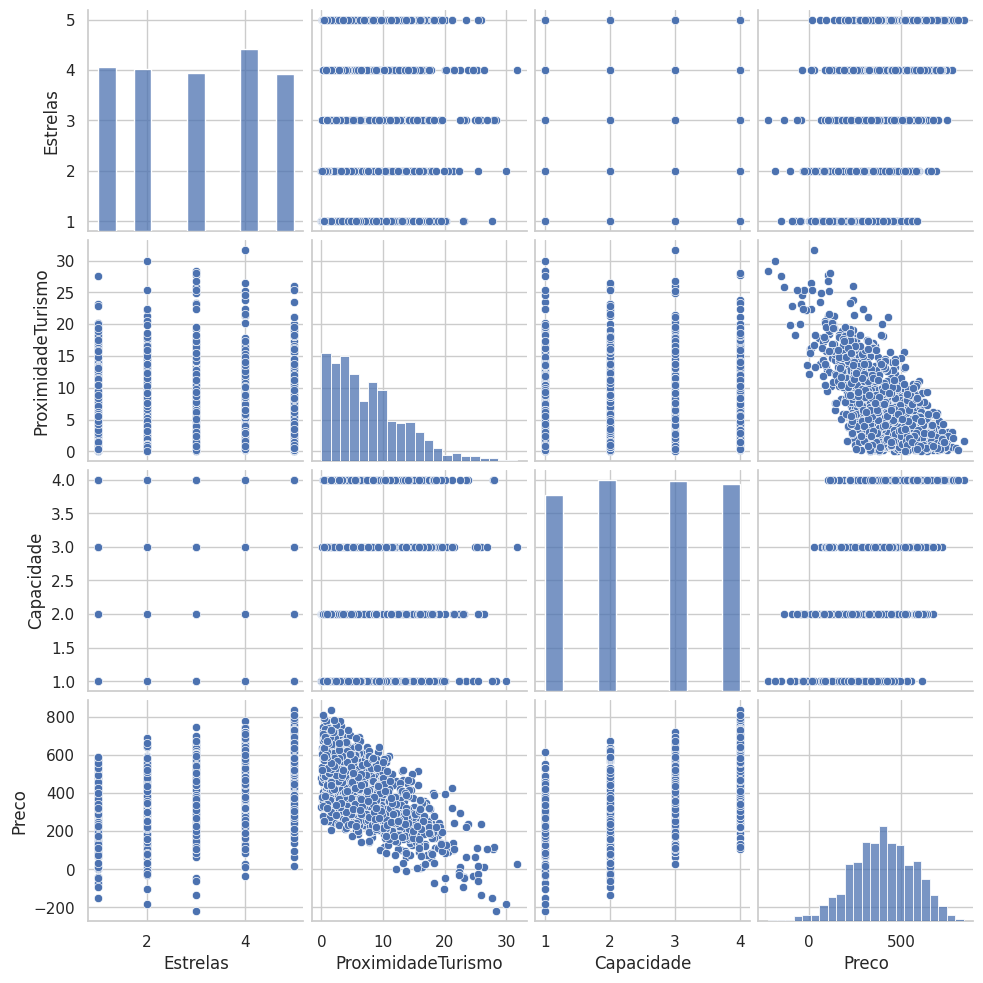

In [626]:
sns.pairplot(hotel)

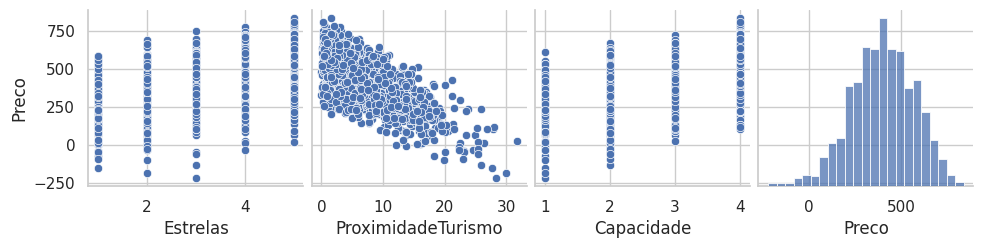

In [627]:
sns.pairplot(hotel,y_vars='Preco')

In [628]:
import statsmodels.api as sm

In [629]:
X1=hotel['Estrelas']
X1=sm.add_constant(X1)
y1=hotel['Preco']
model_1=sm.OLS(y1,X1).fit()

In [630]:
X2=hotel[['Estrelas','ProximidadeTurismo']]
X2=sm.add_constant(X2)
y2=hotel['Preco']
model_2=sm.OLS(y2,X2).fit()

In [631]:
X3=hotel[['Estrelas','ProximidadeTurismo','Capacidade']]
X3=sm.add_constant(X3)
y3=hotel['Preco']
model_3=sm.OLS(y3,X3).fit()

In [632]:
print('Modelo 1 - Estrelas')
print(model_1.summary())
print('Modelo 2 - Estrelas e proximidade turismo')
print(model_2.summary())
print('Modelo 3 - Estrelas, proximidade turismo e Capacidade')
print(model_3.summary())

Modelo 1 - Estrelas
                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     191.3
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.09e-40
Time:                        04:47:55   Log-Likelihood:                -6476.7
No. Observations:                1000   AIC:                         1.296e+04
Df Residuals:                     998   BIC:                         1.297e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        249.3517     11.752

#Guardar Modelos con Pickle

In [633]:
'''
import pickle

# Nombre del archivo donde se guardará el modelo
nombre_archivo = 'modelo_regresion_lineal.pkl'

# Guardar el modelo en un archivo usando pickle
with open(nombre_archivo, 'wb') as archivo:
    pickle.dump(modelo, archivo)

SyntaxError: incomplete input (1138306566.py, line 1)

#Cargar el Modelo de vuelta con Pickle


In [ ]:
'''
# Cargar el modelo de vuelta del archivo
with open(nombre_archivo, 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

#Actividad

Planta de energia:

Primera etapa: Verifica la multicolinealidad utilizando el concepto de VIF. Si hay indicios de multicolinealidad entre las variables, intenta pensar en qué medidas se pueden tomar. Para ello, deberás construir un modelo de regresión lineal asumiendo que la columna PE es la variable y.


Segunda etapa: Realiza un análisis de residuos e identifica si hay o no heterocedasticidad en los datos.

In [639]:
energia=pd.read_csv('/content/drive/MyDrive/Regresion Lineal/usina.csv')
energia.head(2)

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37


In [648]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import statsmodels.api as sm

In [643]:
y=energia['PE']
X=energia.drop(columns=['PE'])

In [644]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=90)

In [645]:
X_train=sm.add_constant(X_train)

In [646]:
model=sm.OLS(y_train,X_train).fit()

In [647]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.190e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:05:30   Log-Likelihood:                -19645.
No. Observations:                6697   AIC:                         3.930e+04
Df Residuals:                    6692   BIC:                         3.933e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        460.9163     11.688     39.434      0.000     438.004     483.829
AT            -1.9726      0.018   -108.177      0.000      -2.008      -1.937
V             -0.2409      0.009    -27.713      0.000      -0.258      -0.224
AP             0.0563      0.011      4.961      0.000       0.034       0.078
RH            -0.1599      0.005    -31.996      0.000      -0.170      -0.150
==============================================================================
Omnibus:                      686.590   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3355.773
Skew:                          -0.383   Prob(JB):                         0.00
Kurtosis:                       6.382   Cond. No.                     2.14e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.14e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [655]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif # Re-importar para asegurar que 'vif' es la función

exp_1=['AT', 'V', 'AP', 'RH']
vif_df=pd.DataFrame()
vif_df['variables']=exp_1
vif_df['vif']=[vif(X_train, i) for i in range(len(exp_1))]
print(vif_df)

  variables           vif
0        AT  44223.249965
1         V      5.948013
2        AP      3.957918
3        RH      1.452856


Velocidad del viento es mayor a 5 por lo que hay presencia de multicolinealidad.

In [656]:
import plotly.express as px
y_previsto_train =  model.predict(X_train)
fig = px.scatter(x=y_previsto_train, y=y_train,
                 title='Previsto vs. Real',
                 labels={'x':'Precio previsto','y':'Precio real'})
fig.show()

In [658]:
# Residuos
residuos = model.resid
fig = px.scatter(x=y_previsto_train, y=residuos,
                 title='Previsto vs. Residuos',
                 labels={'x':'Precio previsto','y':'Residuos'})
fig.show()

Con esto confirmamos que no hay heterocedasticidad en este caso.

[Documentacion Regresion lineal]('https://www.statsmodels.org/stable/regression.html')


[Documentacion Analisis de Regresion lineal]('https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regress%C3%A3o.pdf')